# Stochastic model using Kolmogorov equations

using pasture size A=100

In [1]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

In [2]:
R = 0.00888
K = 0.00772
A = 100

In [3]:
#initial state 25 grass blocks
p0 = np.zeros(A+1)
p0[5]=1

In [4]:
#r matrix

def growthRate(Ng, N):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N):
    return N*R*Ng/A

def rij(i, j, N):
    """value of element r_ij in the r matrix"""

    if i == 0:
        return 0
    elif j == i+1:
        return growthRate(i, N)
    elif i == j+1:
        return eatRate(i, N)
    elif i == j:
        return -growthRate(i, N) - eatRate(i, N)
    else:
        return 0

In [5]:
def rMatrix(N):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N)
    return r_matrix

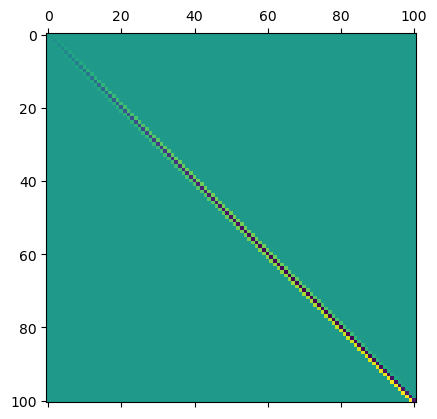

In [6]:
f, ax = plt.subplots()

ax.matshow(rMatrix(int(A*0.4)))

plt.show()

In [7]:
def simulate(N, time, init):
    """return solution to kolmogorov equations given value for N, how long to simulate, and initial condition
    if init is "max", Ng(0) = A
    if init is "eq", Ng(0) is the equilibrium value from the deterministic model
    """
    #R matrix for give value of N
    r_matrix = rMatrix(N)

    #initial value
    p0 = np.zeros(A+1)
    if init == "max":
        p0[A]=1
    elif init == "eq":
        p0[int(A-N*R/K)]=1
    else:
        raise ValueError("init must be \"max\" or \"eq\"")

    #RHS of the system
    def sys(t, y):
        return np.matmul(y, r_matrix)
    s = sp.integrate.solve_ivp(sys, (0, time), p0)
    print("finished solution N={0}, Ng0 {1}".format(N, init))
    return s

In [8]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [9]:
sol_max = {str(i): simulate(i, 3600, "max") for i in range(5, 90, 5)}

sol_eq = {str(i): simulate(i, 3600, "eq") for i in range(5, 90, 5)}

finished solution N=5, Ng0 max
finished solution N=10, Ng0 max
finished solution N=15, Ng0 max
finished solution N=20, Ng0 max
finished solution N=25, Ng0 max
finished solution N=30, Ng0 max
finished solution N=35, Ng0 max
finished solution N=40, Ng0 max
finished solution N=45, Ng0 max
finished solution N=50, Ng0 max
finished solution N=55, Ng0 max
finished solution N=60, Ng0 max
finished solution N=65, Ng0 max
finished solution N=70, Ng0 max
finished solution N=75, Ng0 max
finished solution N=80, Ng0 max
finished solution N=85, Ng0 max
finished solution N=5, Ng0 eq
finished solution N=10, Ng0 eq
finished solution N=15, Ng0 eq
finished solution N=20, Ng0 eq
finished solution N=25, Ng0 eq
finished solution N=30, Ng0 eq
finished solution N=35, Ng0 eq
finished solution N=40, Ng0 eq
finished solution N=45, Ng0 eq
finished solution N=50, Ng0 eq
finished solution N=55, Ng0 eq
finished solution N=60, Ng0 eq
finished solution N=65, Ng0 eq
finished solution N=70, Ng0 eq
finished solution N=75, 

In [10]:
sol_max["30"]["t"]

array([0.00000000e+00, 3.75000188e-03, 4.12500207e-02, 4.16250209e-01,
       1.28666093e+00, 2.36012617e+00, 3.91927998e+00, 6.15048539e+00,
       9.11907833e+00, 1.28645825e+01, 1.73721557e+01, 2.24260748e+01,
       2.78541499e+01, 3.36689011e+01, 4.00836422e+01, 4.55061453e+01,
       5.03173834e+01, 5.51286215e+01, 6.00027786e+01, 6.48811456e+01,
       6.96918294e+01, 7.44339395e+01, 7.91817869e+01, 8.40023795e+01,
       8.88755525e+01, 9.37113036e+01, 9.84564149e+01, 1.03161155e+02,
       1.07924806e+02, 1.12782604e+02, 1.17658194e+02, 1.22449247e+02,
       1.27152026e+02, 1.31868749e+02, 1.36692586e+02, 1.41596395e+02,
       1.46455040e+02, 1.51194211e+02, 1.55881755e+02, 1.60651227e+02,
       1.65549233e+02, 1.70470827e+02, 1.75277099e+02, 1.79964990e+02,
       1.84672399e+02, 1.89522542e+02, 1.94476588e+02, 1.99365123e+02,
       2.04091798e+02, 2.08751149e+02, 2.13520183e+02, 2.18457243e+02,
       2.23418792e+02, 2.28221607e+02, 2.32869198e+02, 2.37546828e+02,
      

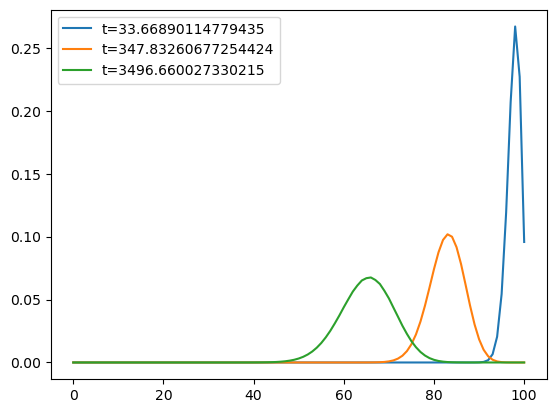

In [15]:
f, ax = plt.subplots()

ax.plot(sol_max["30"]["y"][:,timeToIndex(sol_max["30"]["t"],10)],
        label="t={0}".format(sol_max["30"]["t"][timeToIndex(sol_max["30"]["t"],35)]))

ax.plot(sol_max["30"]["y"][:,timeToIndex(sol_max["30"]["t"],100)],
        label="t={0}".format(sol_max["30"]["t"][timeToIndex(sol_max["30"]["t"],350)]))

ax.plot(sol_max["30"]["y"][:,timeToIndex(sol_max["30"]["t"],1000)],
        label="t={0}".format(sol_max["30"]["t"][timeToIndex(sol_max["30"]["t"],3500)]))

ax.legend()

plt.show()